In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

uploaded = files.upload()

Saving Consumer_Market_Intelligence_Dataset.xlsx to Consumer_Market_Intelligence_Dataset (1).xlsx


In [ ]:
file_name = "Consumer_Market_Intelligence_Dataset (1).xlsx"

customers = pd.read_excel(file_name, sheet_name="Customers")
products = pd.read_excel(file_name, sheet_name="Products")
transactions = pd.read_excel(file_name, sheet_name="Transactions")
calendar = pd.read_excel(file_name, sheet_name="Calendar")
market_benchmark = pd.read_excel(
    file_name,
    sheet_name="Market_Benchmark"
)

print("Customers:", customers.shape)
print("Products:", products.shape)
print("Transactions:", transactions.shape)
print("Calendar:", calendar.shape)
print("Market Benchmark:", market_benchmark.shape)

Customers: (8000, 7)
Products: (45, 6)
Transactions: (60000, 10)
Calendar: (731, 7)
Market Benchmark: (3600, 5)


In [ ]:
transactions.head()

,transaction_id,customer_id,product_id,date,quantity,unit_price,discount_pct,revenue,channel,region
0,T000001,C05101,P045,2025-03-31,2,30.35,0.0550,57.36,E-commerce,Central
1,T000002,C01319,P039,2025-08-28,2,47.37,0.0333,91.58,Supermarket,West
2,T000003,C01464,P042,2025-10-19,2,39.81,0.0837,72.96,Convenience,West
3,T000004,C01585,P012,2024-02-28,4,137.59,0.1571,463.88,Convenience,East
4,T000005,C00570,P002,2025-05-29,2,87.29,0.1113,155.14,Supermarket,Central


In [ ]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  60000 non-null  object        
 1   customer_id     60000 non-null  object        
 2   product_id      60000 non-null  object        
 3   date            60000 non-null  datetime64[ns]
 4   quantity        60000 non-null  int64         
 5   unit_price      60000 non-null  float64       
 6   discount_pct    60000 non-null  float64       
 7   revenue         60000 non-null  float64       
 8   channel         60000 non-null  object        
 9   region          60000 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(5)
memory usage: 4.6+ MB


In [ ]:
print("Missing values in Customers:")
print(customers.isnull().sum())

print("\nMissing values in Products:")
print(products.isnull().sum())

print("\nMissing values in Transactions:")
print(transactions.isnull().sum())

Missing values in Customers:
customer_id          0
age                  0
gender               0
annual_income_inr    0
city                 0
region               0
customer_segment     0
dtype: int64

Missing values in Products:
product_id      0
product_name    0
category        0
brand           0
pack_size       0
list_price      0
dtype: int64

Missing values in Transactions:
transaction_id    0
customer_id       0
product_id        0
date              0
quantity          0
unit_price        0
discount_pct      0
revenue           0
channel           0
region            0
dtype: int64


In [ ]:
transactions["date"] = pd.to_datetime(transactions["date"])
calendar["date"] = pd.to_datetime(calendar["date"])

print("Transaction date range:")
print(transactions["date"].min(), "to", transactions["date"].max())

Transaction date range:
2024-01-01 00:00:00 to 2025-12-31 00:00:00


In [ ]:
analysis_df = transactions.merge(
    customers,
    on="customer_id",
    how="left"
)

analysis_df = analysis_df.merge(
    products,
    on="product_id",
    how="left"
)

print("Analysis dataset shape:", analysis_df.shape)
analysis_df.head()

Analysis dataset shape: (60000, 21)


,transaction_id,customer_id,product_id,date,quantity,unit_price,discount_pct,revenue,channel,region_x,...,gender,annual_income_inr,city,region_y,customer_segment,product_name,category,brand,pack_size,list_price
0,T000001,C05101,P045,2025-03-31,2,30.35,0.0550,57.36,E-commerce,Central,...,Female,71053,Raipur,Central,Premium,BlueDrop 1L,Packaged Water,BlueDrop,1L,30.35
1,T000002,C01319,P039,2025-08-28,2,47.37,0.0333,91.58,Supermarket,West,...,Male,15032,Pune,West,Value,ClearSpring 1L,Packaged Water,ClearSpring,1L,47.37
2,T000003,C01464,P042,2025-10-19,2,39.81,0.0837,72.96,Convenience,West,...,Female,37629,Mumbai,West,Mass Market,AquaPure 1L,Packaged Water,AquaPure,1L,39.81
3,T000004,C01585,P012,2024-02-28,4,137.59,0.1571,463.88,Convenience,East,...,Male,38920,Guwahati,East,Mass Market,PureSip 1L,Juices,PureSip,1L,137.59
4,T000005,C00570,P002,2025-05-29,2,87.29,0.1113,155.14,Supermarket,Central,...,Female,32716,Bhopal,Central,Value,FizzUp 500ml,Carbonated Drinks,FizzUp,500ml,87.29


In [ ]:
analysis_df[
    ["quantity", "unit_price", "discount_pct", "revenue"]
].describe()

,quantity,unit_price,discount_pct,revenue
count,60000.000000,60000.000000,60000.000000,60000.000000
mean,2.691850,78.840113,0.088671,193.554752
std,1.303542,35.075932,0.050538,134.758334
min,1.000000,21.380000,0.000000,16.450000
25%,2.000000,47.370000,0.051500,91.160000
50%,3.000000,75.260000,0.086900,157.725000
75%,3.000000,109.310000,0.123400,260.642500
max,10.000000,147.250000,0.300000,1178.000000


Cell 8 — Customer-level **metrics**

In [ ]:
customer_analysis = (
    analysis_df
    .groupby(["customer_id", "customer_segment", "age", "gender", "region_y"])
    .agg(
        total_spend=("revenue", "sum"),
        total_transactions=("transaction_id", "count"),
        total_units=("quantity", "sum"),
        avg_transaction_value=("revenue", "mean")
    )
    .reset_index()
)

customer_analysis.head()

,customer_id,customer_segment,age,gender,region_y,total_spend,total_transactions,total_units,avg_transaction_value
0,C00001,Value,41,Male,West,1644.08,8,24,205.510000
1,C00002,Premium,36,Male,South,2945.93,13,39,226.610000
2,C00003,Value,36,Female,East,1332.89,7,17,190.412857
3,C00004,Premium,22,Male,East,1267.66,8,25,158.457500
4,C00005,Value,42,Female,North,1652.26,7,20,236.037143


Cell 9 — Summary **statistics**

In [ ]:
customer_analysis[
    [
        "total_spend",
        "total_transactions",
        "total_units",
        "avg_transaction_value"
    ]
].describe()

,total_spend,total_transactions,total_units,avg_transaction_value
count,7993.000000,7993.000000,7993.000000,7993.000000
mean,1452.931957,7.506568,20.206556,193.375299
std,643.417685,2.719814,8.132166,52.760479
min,36.690000,1.000000,1.000000,36.690000
25%,997.360000,6.000000,14.000000,157.317500
50%,1387.170000,7.000000,19.000000,188.311429
75%,1841.270000,9.000000,25.000000,224.110000
max,4349.070000,19.000000,56.000000,485.343333


Cell 10 — Top 10 customers by **spending**

In [ ]:
top_customers = (
    customer_analysis
    .sort_values("total_spend", ascending=False)
    .head(10)
)

top_customers[
    [
        "customer_id",
        "customer_segment",
        "region_y",
        "total_spend",
        "total_transactions"
    ]
]

,customer_id,customer_segment,region_y,total_spend,total_transactions
3036,C03038,Mass Market,South,4349.07,19
2502,C02504,Mass Market,South,4235.33,14
2378,C02380,Premium,South,4150.62,17
1033,C01034,Premium,South,4058.14,15
2788,C02790,Mass Market,South,4018.48,13
658,C00659,Value,North,4004.64,12
5282,C05285,Affluent,East,3956.07,14
3776,C03778,Mass Market,Central,3936.74,15
3031,C03033,Mass Market,North,3897.98,19
3344,C03346,Value,South,3869.48,16


Cell 11 — Customer spending **distribution**

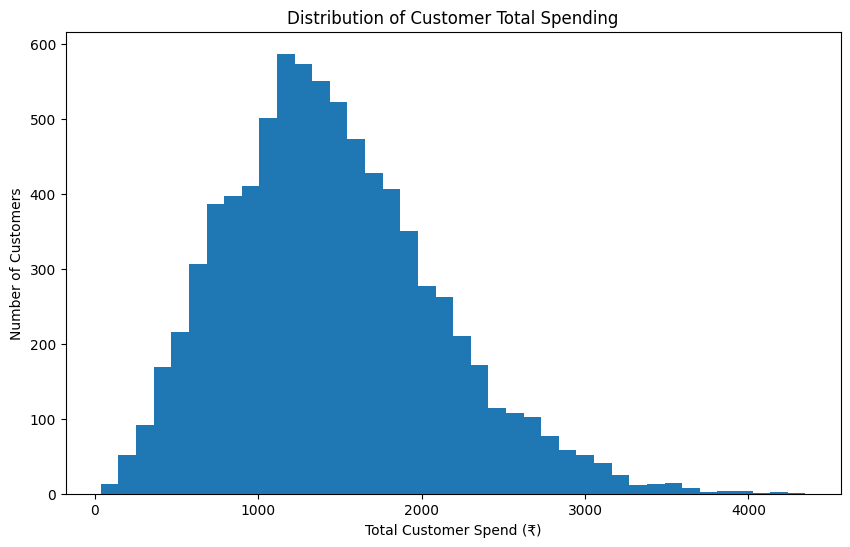

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    customer_analysis["total_spend"],
    bins=40
)

plt.title("Distribution of Customer Total Spending")
plt.xlabel("Total Customer Spend (₹)")
plt.ylabel("Number of Customers")

plt.show()

**Cell 12 — Purchase frequency distribution**

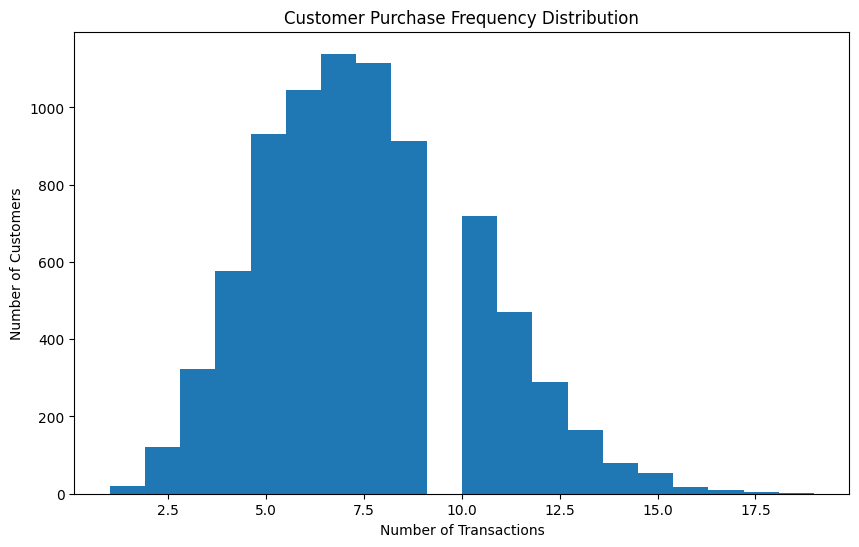

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    customer_analysis["total_transactions"],
    bins=20
)

plt.title("Customer Purchase Frequency Distribution")
plt.xlabel("Number of Transactions")
plt.ylabel("Number of Customers")

plt.show()

Cell 13 — Segment **summary**

In [ ]:
segment_analysis = (
    customer_analysis
    .groupby("customer_segment")
    .agg(
        customers=("customer_id", "nunique"),
        avg_spend=("total_spend", "mean"),
        median_spend=("total_spend", "median"),
        avg_transactions=("total_transactions", "mean"),
        avg_units=("total_units", "mean"),
        avg_transaction_value=("avg_transaction_value", "mean")
    )
    .reset_index()
)

segment_analysis.sort_values(
    "avg_spend",
    ascending=False
)

,customer_segment,customers,avg_spend,median_spend,avg_transactions,avg_units,avg_transaction_value
2,Premium,1743,1464.435479,1398.970,7.519793,20.087206,194.527991
1,Mass Market,3600,1453.025572,1387.355,7.538056,20.342778,192.565786
3,Value,2013,1451.383691,1379.730,7.507700,20.230502,193.130654
0,Affluent,637,1425.818932,1382.920,7.288854,19.687598,195.569296


Cell 14 — Add percentage **contribution**

In [ ]:
segment_analysis["revenue_contribution_pct"] = (
    segment_analysis["avg_spend"] *
    segment_analysis["customers"]
)

segment_analysis["revenue_contribution_pct"] = (
    100 *
    segment_analysis["revenue_contribution_pct"] /
    segment_analysis["revenue_contribution_pct"].sum()
)

segment_analysis.sort_values(
    "revenue_contribution_pct",
    ascending=False
)

,customer_segment,customers,avg_spend,median_spend,avg_transactions,avg_units,avg_transaction_value,revenue_contribution_pct
1,Mass Market,3600,1453.025572,1387.355,7.538056,20.342778,192.565786,45.042311
3,Value,2013,1451.383691,1379.730,7.507700,20.230502,193.130654,25.157699
2,Premium,1743,1464.435479,1398.970,7.519793,20.087206,194.527991,21.979233
0,Affluent,637,1425.818932,1382.920,7.288854,19.687598,195.569296,7.820756


**Cell 15 — Segment spending visualization**

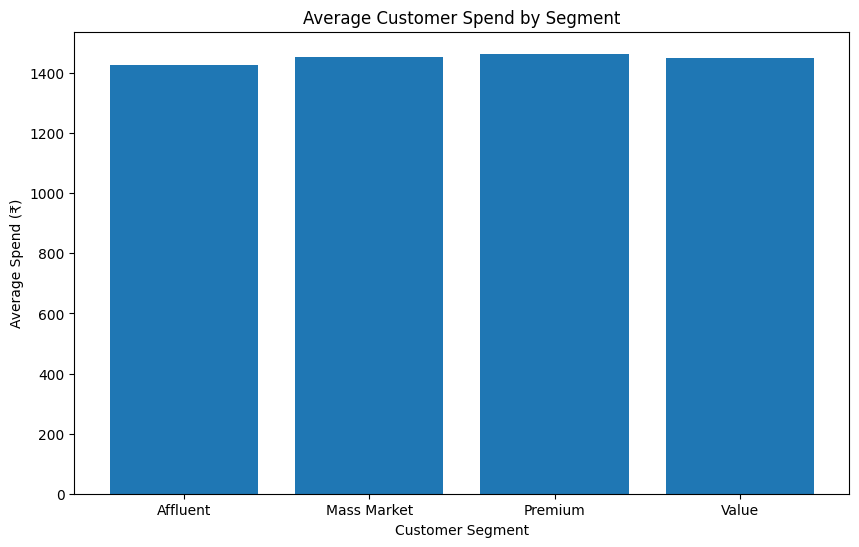

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_analysis["customer_segment"],
    segment_analysis["avg_spend"]
)

plt.title("Average Customer Spend by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Spend (₹)")

plt.show()

Cell 16 — Segment purchase frequency

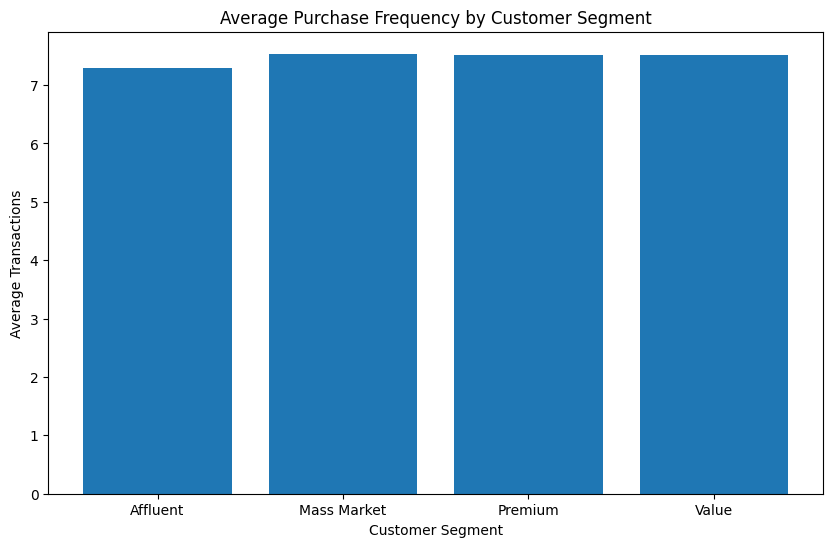

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_analysis["customer_segment"],
    segment_analysis["avg_transactions"]
)

plt.title("Average Purchase Frequency by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Transactions")

plt.show()

Cell 17 — Region × Category performance

In [ ]:
region_category = (
    analysis_df
    .groupby(["region_x", "category"])
    .agg(
        revenue=("revenue", "sum"),
        units=("quantity", "sum"),
        transactions=("transaction_id", "count")
    )
    .reset_index()
)

region_category["avg_transaction_value"] = (
    region_category["revenue"] /
    region_category["transactions"]
)

region_category = region_category.sort_values(
    "revenue",
    ascending=False
)

region_category.head(15)

,region_x,category,revenue,units,transactions,avg_transaction_value
22,South,Juices,777822.64,8937,3308,235.133809
26,West,Energy Drinks,713472.23,7011,2621,272.213747
21,South,Energy Drinks,700054.37,6856,2575,271.865775
27,West,Juices,633539.61,7253,2703,234.383873
12,North,Juices,626763.85,7242,2675,234.304243
10,North,Carbonated Drinks,578481.30,10142,3740,154.674144
20,South,Carbonated Drinks,576849.98,10211,3773,152.888942
11,North,Energy Drinks,575699.19,5665,2099,274.273078
25,West,Carbonated Drinks,574213.46,10122,3804,150.949911
24,South,Sports Drinks,548522.31,5414,2026,270.741515


Cell 18 — Best category within each region

In [ ]:
top_category_by_region = (
    region_category
    .sort_values(
        ["region_x", "revenue"],
        ascending=[True, False]
    )
    .groupby("region_x")
    .head(1)
)

top_category_by_region

,region_x,category,revenue,units,transactions,avg_transaction_value
2,Central,Juices,440909.93,5061,1888,233.532802
7,East,Juices,440748.43,5070,1865,236.326236
12,North,Juices,626763.85,7242,2675,234.304243
17,Northeast,Juices,155693.52,1800,672,231.686786
22,South,Juices,777822.64,8937,3308,235.133809
26,West,Energy Drinks,713472.23,7011,2621,272.213747


Cell 19 — Region × Category heatmap

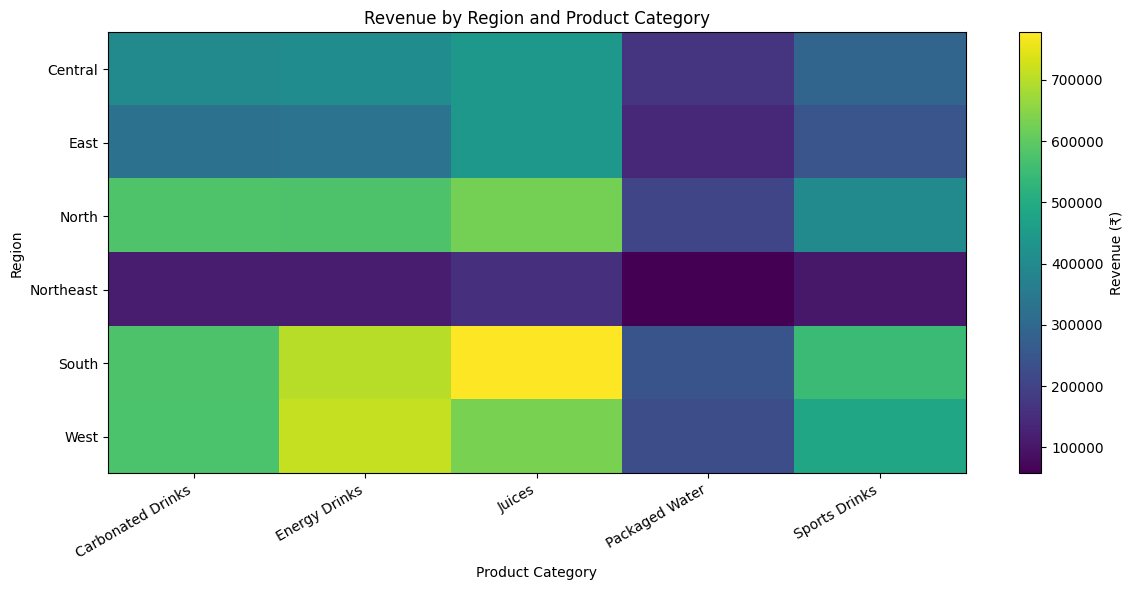

In [ ]:
pivot_region_category = region_category.pivot(
    index="region_x",
    columns="category",
    values="revenue"
)

plt.figure(figsize=(12, 6))

plt.imshow(pivot_region_category, aspect="auto")

plt.xticks(
    range(len(pivot_region_category.columns)),
    pivot_region_category.columns,
    rotation=30,
    ha="right"
)

plt.yticks(
    range(len(pivot_region_category.index)),
    pivot_region_category.index
)

plt.title("Revenue by Region and Product Category")
plt.xlabel("Product Category")
plt.ylabel("Region")

plt.colorbar(label="Revenue (₹)")

plt.tight_layout()
plt.show()

Cell 20 — Price and discount correlation

In [ ]:
price_discount_analysis = analysis_df[
    ["unit_price", "discount_pct", "quantity", "revenue"]
].corr()

price_discount_analysis

,unit_price,discount_pct,quantity,revenue
unit_price,1.000000,-0.002503,0.002045,0.640515
discount_pct,-0.002503,1.000000,-0.008799,-0.087882
quantity,0.002045,-0.008799,1.000000,0.697152
revenue,0.640515,-0.087882,0.697152,1.000000


Cell 21 — Discount vs Revenue


In [ ]:
discount_analysis = (
    analysis_df
    .assign(
        discount_band=pd.cut(
            analysis_df["discount_pct"],
            bins=[-0.001, 0.05, 0.10, 0.15, 0.20, 0.30],
            labels=[
                "0–5%",
                "5–10%",
                "10–15%",
                "15–20%",
                "20–30%"
            ]
        )
    )
    .groupby("discount_band", observed=True)
    .agg(
        transactions=("transaction_id", "count"),
        avg_revenue=("revenue", "mean"),
        total_revenue=("revenue", "sum"),
        avg_units=("quantity", "mean")
    )
    .reset_index()
)

discount_analysis

,discount_band,transactions,avg_revenue,total_revenue,avg_units
0,0–5%,14466,209.829524,3035393.90,2.718305
1,5–10%,21388,195.148248,4173830.72,2.687255
2,10–15%,17035,186.757313,3181410.83,2.687526
3,15–20%,6053,172.563058,1044524.19,2.641830
4,20–30%,1058,168.360577,178125.49,2.778828


Cell 22 — Visualize discount bands

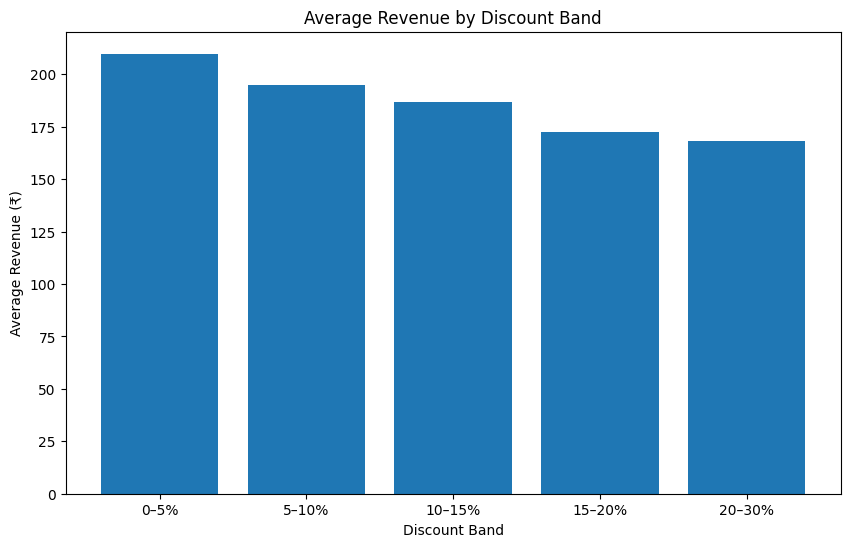

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    discount_analysis["discount_band"],
    discount_analysis["avg_revenue"]
)

plt.title("Average Revenue by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Average Revenue (₹)")

plt.show()

Cell 23 — Age and income vs spending

In [ ]:
demographic_analysis = (
    customer_analysis
    .merge(customers[['customer_id', 'annual_income_inr']], on='customer_id', how='left')
)

demographic_analysis[
    ["age", "annual_income_inr", "total_spend"]
].corr()

,age,annual_income_inr,total_spend
age,1.000000,0.012181,0.023250
annual_income_inr,0.012181,1.000000,-0.003609
total_spend,0.023250,-0.003609,1.000000


Cell 24 — Create age groups

In [ ]:
demographic_analysis["age_group"] = pd.cut(
    demographic_analysis["age"],
    bins=[17, 24, 34, 44, 54, 65],
    labels=[
        "18–24",
        "25–34",
        "35–44",
        "45–54",
        "55–65"
    ]
)

age_analysis = (
    demographic_analysis
    .groupby("age_group", observed=True)
    .agg(
        customers=("customer_id", "count"),
        avg_spend=("total_spend", "mean"),
        median_spend=("total_spend", "median"),
        avg_transactions=("total_transactions", "mean")
    )
    .reset_index()
)

age_analysis

,age_group,customers,avg_spend,median_spend,avg_transactions
0,18–24,1352,1440.966065,1371.945,7.500740
1,25–34,2724,1435.216300,1387.285,7.403818
2,35–44,2707,1478.041991,1397.910,7.618397
3,45–54,1039,1444.963600,1390.040,7.487007
4,55–65,171,1480.660585,1387.290,7.538012


Cell 25 — Income groups

In [ ]:
demographic_analysis["income_group"] = pd.qcut(
    demographic_analysis["annual_income_inr"],
    q=4,
    labels=[
        "Low Income",
        "Lower-Middle Income",
        "Upper-Middle Income",
        "High Income"
    ]
)

income_analysis = (
    demographic_analysis
    .groupby("income_group", observed=True)
    .agg(
        customers=("customer_id", "count"),
        avg_income=("annual_income_inr", "mean"),
        avg_spend=("total_spend", "mean"),
        median_spend=("total_spend", "median"),
        avg_transactions=("total_transactions", "mean")
    )
    .reset_index()
)

income_analysis

,income_group,customers,avg_income,avg_spend,median_spend,avg_transactions
0,Low Income,1999,22539.819910,1442.100535,1358.130,7.471736
1,Lower-Middle Income,1998,35664.418418,1458.355255,1411.825,7.575075
2,Upper-Middle Income,1998,51497.124625,1463.248128,1387.705,7.547047
3,High Income,1998,101788.326326,1448.029329,1389.990,7.432432


Cell 26 — Income vs customer spending

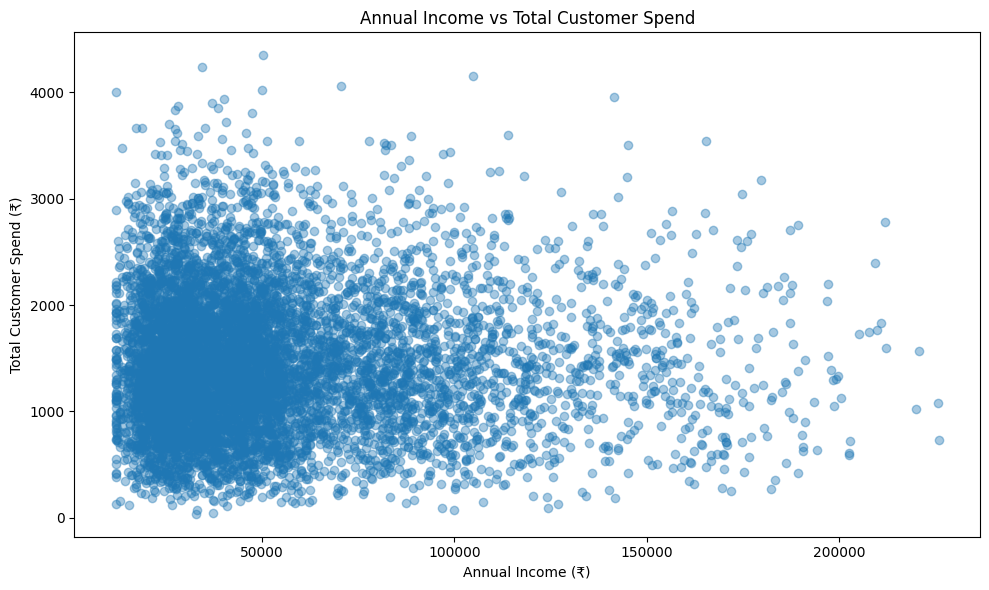

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    demographic_analysis["annual_income_inr"],
    demographic_analysis["total_spend"],
    alpha=0.4
)

plt.title("Annual Income vs Total Customer Spend")
plt.xlabel("Annual Income (₹)")
plt.ylabel("Total Customer Spend (₹)")

plt.tight_layout()
plt.show()